In [1]:
library(purrr)
library(tidyverse)
library(edgeR)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: limma



In [2]:
# Read the csv file
piRNAData <- read.csv("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/seqCount/alinged_count_matrix_20.5dpp.txt", header = TRUE, row.names = 1,sep='\t')#, nrows = 10000
piRNAData 


,X129S1_SvImJ.20.5dpp.1,X129S1_SvImJ.20.5dpp.2,X129S1_SvImJ.20.5dpp.3,A_J.20.5dpp.1,A_J.20.5dpp.2,A_J.20.5dpp.3,AKR_J.20.5dpp.1,AKR_J.20.5dpp.2,AKR_J.20.5dpp.3,BALB_cJ.20.5dpp.1,⋯,NZO_HlLtJ.20.5dpp.3,PWK_PhJ.20.5dpp.1,PWK_PhJ.20.5dpp.2,PWK_PhJ.20.5dpp.3,SPRET_EiJ.20.5dpp.1,SPRET_EiJ.20.5dpp.2,SPRET_EiJ.20.5dpp.3,WSB_EiJ.20.5dpp.1,WSB_EiJ.20.5dpp.2,WSB_EiJ.20.5dpp.3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,157578,146335,112076,74341,76192,67069,141966,146425,148563,239560,⋯,49435,68379,117786,205829,147823,249290,306409,297960,117708,108775
TCAATAAATATTTGTAGAATGCATGAATGA,76149,79203,81774,35737,38597,40075,38650,44110,48610,251788,⋯,143392,70753,103942,193119,100422,167439,211545,222164,136230,133487
TACCAGTTGGATAATGCACTTCCTATT,70603,64361,77282,40620,46322,59940,23403,26824,24752,292519,⋯,79884,71857,96847,199056,0,0,0,248843,213423,194029
TTGGAGATTGAATTTTTGAAAAAGCCT,39536,28920,29232,27896,32949,33473,20619,22799,26373,98191,⋯,37406,0,0,0,0,0,0,87380,47803,45412
ATGCATTGTAGGATGATTGGCACTATC,36554,38121,28585,27590,28007,25447,22691,25976,32666,69773,⋯,18271,11976,26611,49112,23436,40160,65276,77353,28916,23571
TGATACAATTTCTAAGGGCTGTTTAGTAAT,35860,32512,28587,17198,20363,19758,30034,33618,31523,72267,⋯,17010,17555,30337,49642,29858,42739,64618,91029,37690,29794
TAAGATCAGCCAGACAGGACTCTGCCT,34915,26375,26879,15933,17433,20182,11458,12240,13854,90680,⋯,36439,28027,32514,70818,22320,37121,54822,76010,45136,44379
TACAAAGGAGCGAAAGGACTACCTGTCACC,32068,37139,29619,0,0,0,10969,12475,13298,92231,⋯,20629,18694,29062,51363,30637,49648,68072,55273,34503,33291
TAACGTACGTATGTTTGAAATGTGACT,31067,27542,35762,15956,19792,25843,10003,12652,9502,148630,⋯,47590,41641,50369,114932,51216,85342,88162,118975,115921,113076


In [3]:
sampleName = c('129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','A_J-P20.5','A_J-P20.5','A_J-P20.5','AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5','CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5','LP_J-P20.5','LP_J-P20.5','LP_J-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','NZO_HlLtJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5')

lablesName = c('129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3','A_J-P20.5.1','A_J-P20.5.2','A_J-P20.5.3','AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3','BALB_cJ-P20.5.1','BALB_cJ-P20.5.2','BALB_cJ-P20.5.3','C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3','C57BL_6NJ-P20.5.1','C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3','CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3','CBA_J-P20.5.1','CBA_J-P20.5.2','CBA_J-P20.5.3','DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3','FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3','LP_J-P20.5.1','LP_J-P20.5.2','LP_J-P20.5.3','NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3','NZO_HlLtJ-P20.5.1','NZO_HlLtJ-P20.5.2','NZO_HlLtJ-P20.5.3','PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3','SPRET_EiJ-P20.5.1','SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3','WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3')

#samplenames = tools::file_path_sans_ext(tools::file_path_sans_ext(sub(".*/", "", f_files,perl = T)))
sampleNames_order = c('C57BL_6NJ-P20.5','C57BL_6NJ-P20.5','C57BL_6NJ-P20.5',
'BALB_cJ-P20.5','BALB_cJ-P20.5','BALB_cJ-P20.5',
'A_J-P20.5','A_J-P20.5','A_J-P20.5',
'FVB_NJ-P20.5','FVB_NJ-P20.5','FVB_NJ-P20.5',
'C3H_HeJ-P20.5','C3H_HeJ-P20.5','C3H_HeJ-P20.5',
'129S1_SvImJ-P20.5','129S1_SvImJ-P20.5','129S1_SvImJ-P20.5',
'DBA_2J-P20.5','DBA_2J-P20.5','DBA_2J-P20.5',
'AKR_J-P20.5','AKR_J-P20.5','AKR_J-P20.5',
'CBA_J-P20.5','CBA_J-P20.5','CBA_J-P20.5',
'NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5','NOD_ShiLtJ-P20.5',
'WSB_EiJ-P20.5','WSB_EiJ-P20.5','WSB_EiJ-P20.5',
'CAST_EiJ-P20.5','CAST_EiJ-P20.5','CAST_EiJ-P20.5',
'PWK_PhJ-P20.5','PWK_PhJ-P20.5','PWK_PhJ-P20.5',
'SPRET_EiJ-P20.5','SPRET_EiJ-P20.5','SPRET_EiJ-P20.5')

lablesName_order = c('C57BL_6NJ-P20.5.1','C57BL_6NJ-P20.5.2','C57BL_6NJ-P20.5.3',
'BALB_cJ-P20.5.1','BALB_cJ-P20.5.2','BALB_cJ-P20.5.3',
'A_J-P20.5.1','A_J-P20.5.2','A_J-P20.5.3',
'FVB_NJ-P20.5.1','FVB_NJ-P20.5.2','FVB_NJ-P20.5.3',
'C3H_HeJ-P20.5.1','C3H_HeJ-P20.5.2','C3H_HeJ-P20.5.3',
'129S1_SvImJ-P20.5.1','129S1_SvImJ-P20.5.2','129S1_SvImJ-P20.5.3',
'DBA_2J-P20.5.1','DBA_2J-P20.5.2','DBA_2J-P20.5.3',
'AKR_J-P20.5.1','AKR_J-P20.5.2','AKR_J-P20.5.3',
'CBA_J-P20.5.1','CBA_J-P20.5.2','CBA_J-P20.5.3',
'NOD_ShiLtJ-P20.5.1','NOD_ShiLtJ-P20.5.2','NOD_ShiLtJ-P20.5.3',
'WSB_EiJ-P20.5.1','WSB_EiJ-P20.5.2','WSB_EiJ-P20.5.3',
'CAST_EiJ-P20.5.1','CAST_EiJ-P20.5.2','CAST_EiJ-P20.5.3',
'PWK_PhJ-P20.5.1','PWK_PhJ-P20.5.2','PWK_PhJ-P20.5.3',
'SPRET_EiJ-P20.5.1','SPRET_EiJ-P20.5.2','SPRET_EiJ-P20.5.3')

In [4]:
#change columns names 

colnames(piRNAData) <- lablesName 
piRNAData 

,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P20.5.1,A_J-P20.5.2,A_J-P20.5.3,AKR_J-P20.5.1,AKR_J-P20.5.2,AKR_J-P20.5.3,BALB_cJ-P20.5.1,⋯,NZO_HlLtJ-P20.5.3,PWK_PhJ-P20.5.1,PWK_PhJ-P20.5.2,PWK_PhJ-P20.5.3,SPRET_EiJ-P20.5.1,SPRET_EiJ-P20.5.2,SPRET_EiJ-P20.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,157578,146335,112076,74341,76192,67069,141966,146425,148563,239560,⋯,49435,68379,117786,205829,147823,249290,306409,297960,117708,108775
TCAATAAATATTTGTAGAATGCATGAATGA,76149,79203,81774,35737,38597,40075,38650,44110,48610,251788,⋯,143392,70753,103942,193119,100422,167439,211545,222164,136230,133487
TACCAGTTGGATAATGCACTTCCTATT,70603,64361,77282,40620,46322,59940,23403,26824,24752,292519,⋯,79884,71857,96847,199056,0,0,0,248843,213423,194029
TTGGAGATTGAATTTTTGAAAAAGCCT,39536,28920,29232,27896,32949,33473,20619,22799,26373,98191,⋯,37406,0,0,0,0,0,0,87380,47803,45412
ATGCATTGTAGGATGATTGGCACTATC,36554,38121,28585,27590,28007,25447,22691,25976,32666,69773,⋯,18271,11976,26611,49112,23436,40160,65276,77353,28916,23571
TGATACAATTTCTAAGGGCTGTTTAGTAAT,35860,32512,28587,17198,20363,19758,30034,33618,31523,72267,⋯,17010,17555,30337,49642,29858,42739,64618,91029,37690,29794
TAAGATCAGCCAGACAGGACTCTGCCT,34915,26375,26879,15933,17433,20182,11458,12240,13854,90680,⋯,36439,28027,32514,70818,22320,37121,54822,76010,45136,44379
TACAAAGGAGCGAAAGGACTACCTGTCACC,32068,37139,29619,0,0,0,10969,12475,13298,92231,⋯,20629,18694,29062,51363,30637,49648,68072,55273,34503,33291
TAACGTACGTATGTTTGAAATGTGACT,31067,27542,35762,15956,19792,25843,10003,12652,9502,148630,⋯,47590,41641,50369,114932,51216,85342,88162,118975,115921,113076


In [5]:
setwd("/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/sRNA_deseq/seqCount")

In [6]:
# Now we build a DESeq2 Count dataset and normalize it.
library(DESeq2)
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

conds = data.frame(sampleName) ##what Desq2 manual calls coldata
colnames(conds)="sample"
cds <- DESeqDataSetFromMatrix(countData = piRNAData , colData = conds, design = ~ sample)
#cds <- estimateSizeFactors(cds)
#cds <- estimateDispersions(cds)
#cds <- nbinomWaldTest(cds)
cds <- DESeq(cds, parallel = TRUE)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objec

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates: 124 workers

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, nu

In [7]:
norm_counts <-counts(cds,normalized=TRUE)
norm_counts

,129S1_SvImJ-P20.5.1,129S1_SvImJ-P20.5.2,129S1_SvImJ-P20.5.3,A_J-P20.5.1,A_J-P20.5.2,A_J-P20.5.3,AKR_J-P20.5.1,AKR_J-P20.5.2,AKR_J-P20.5.3,BALB_cJ-P20.5.1,⋯,NZO_HlLtJ-P20.5.3,PWK_PhJ-P20.5.1,PWK_PhJ-P20.5.2,PWK_PhJ-P20.5.3,SPRET_EiJ-P20.5.1,SPRET_EiJ-P20.5.2,SPRET_EiJ-P20.5.3,WSB_EiJ-P20.5.1,WSB_EiJ-P20.5.2,WSB_EiJ-P20.5.3
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,283092.27,266130.09,202485.180,146072.015,130192.171,99222.253,272921.862,243926.18,259883.34,109073.114,⋯,108311.25,107796.583,118127.304,112523.205,165766.143,178603.715,179904.467,113722.72,70890.50,75854.15
TCAATAAATATTTGTAGAATGCATGAATGA,136803.32,144041.42,147739.241,70219.335,65952.163,59287.179,74302.509,73481.88,85034.16,114640.596,⋯,314169.44,111539.093,104243.188,105574.865,112611.486,119961.601,124206.177,84793.58,82045.51,93087.04
TACCAGTTGGATAATGCACTTCCTATT,126839.81,117049.23,139623.646,79813.901,79152.165,88675.570,44990.986,44685.51,43299.02,133185.666,⋯,175024.49,113279.502,97127.630,108820.522,0.000,0.000,0.000,94976.18,128535.56,135305.96
TTGGAGATTGAATTTTTGAAAAAGCCT,71027.28,52594.95,52812.795,54812.619,56301.211,49520.143,39638.899,37980.35,46134.66,44706.955,⋯,81955.91,0.000,0.000,0.000,0.000,0.000,0.000,33350.42,28789.71,31668.02
ATGCATTGTAGGATGATTGGCACTATC,65670.05,69328.22,51643.874,54211.362,47856.627,37646.434,43622.205,43272.85,57143.09,31768.068,⋯,40031.45,18879.654,26688.110,26848.693,26280.723,28772.615,38326.041,29523.41,17414.87,16437.22
TGATACAATTTCTAAGGGCTGTTTAGTAAT,64423.26,59127.49,51647.488,33792.208,34795.033,29230.095,57738.721,56003.49,55143.63,32903.601,⋯,37268.62,27674.710,30424.906,27138.435,33482.242,30620.338,37939.704,34743.14,22699.08,20776.82
TAAGATCAGCCAGACAGGACTCTGCCT,62725.55,47966.52,48561.683,31306.620,29788.431,29857.363,22027.378,20390.35,24235.00,41287.151,⋯,79837.23,44183.373,32608.214,38714.993,25029.260,26595.325,32188.097,29010.82,27183.48,30947.66
TACAAAGGAGCGAAAGGACTACCTGTCACC,57610.85,67542.32,53511.979,0.000,0.000,0.000,21087.302,20781.83,23262.38,41993.331,⋯,45197.79,29470.295,29146.212,28079.276,34355.799,35570.289,39967.680,21096.11,20779.68,23215.45
TAACGTACGTATGTTTGAAATGTGACT,55812.53,50088.87,64610.398,31351.812,33819.344,38232.278,19230.220,21076.69,16621.98,67672.136,⋯,104268.88,65645.264,50514.952,62831.365,57432.732,61143.240,51763.289,45409.32,69814.27,78853.45
TATGTGAATTTCAACTGTTGGCTCCACAGG,52036.25,66854.88,51864.289,38657.280,36091.965,29934.292,99863.341,91773.22,105578.10,39891.183,⋯,35033.82,22053.063,25723.322,23281.587,38497.065,38329.336,47291.643,42284.20,28309.71,33169.41


In [8]:
library(MGFR)
markers.list <- getMarkerGenes.rnaseq(norm_counts, class.vec = sampleName ,samples2compare="all",score.cuto=0.5)

write.csv(t(sapply(markers.list, unlist)), file = "P20.5_marker_alinged.tab")
write.csv(rapply(markers.list, length, how="list"), file = "P20.5_marker_alinged_count.tab")
# Convert the list to FASTA format with unique headers
convert_to_fasta <- function(data_list, output_file) {
  con <- file(output_file, "w")
  header_count <- list()
  
  for (name in names(data_list)) {
    sequences <- unlist(strsplit(data_list[[name]], "'"))
    
    for (seq_info in sequences) {
      split_data <- unlist(strsplit(seq_info, " : "))
      if(length(split_data) == 2) {
        sequence <- split_data[1]
        value <- split_data[2]
        
        # Construct the base header and then check for repetitions
        base_header <- paste(name, "_", value, sep="")
        if (!base_header %in% names(header_count)) {
          header_count[[base_header]] <- 1
          header <- paste(">", base_header, sep="")
        } else {
          header_count[[base_header]] <- header_count[[base_header]] + 1
          header <- paste(">", base_header, "_", header_count[[base_header]], sep="")
        }
        
        cat(header, "\n", sequence, "\n", file=con)
      }
    }
  }
  close(con)
}

# Call the function to write to a FASTA file
convert_to_fasta(markers.list, "P20.5_marker_alinged.fasta")

Detecting marker genes...
Done! 


In [9]:
pdf("P20.5_deseq2_BarGraphBeforeAfter.pdf",paper="a4")
par(mfrow=c(2,1))

par(mar=c(10,4,0,2)) # increase y-axis margin.
prenorm=apply(piRNAData ,2,sum)
barplot(prenorm,col=as.factor(sampleName),las=2,names=sampleName, cex.names = 0.6, cex.axis = 0.8)
postnorm=apply(norm_counts ,2,sum)
barplot(postnorm,col=as.factor(sampleName),las=2,names=sampleName ,cex.names = 0.6, cex.axis = 0.8)
dev.off()




png 
  2

In [10]:
library(gplots)
library(RColorBrewer)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggrepel)

# Make a color scheme for heatmaps
hmcol = colorRampPalette(brewer.pal(9, "GnBu"))(100)
# First we tell DESeq which samples correspond to which tissues.

pdf("P20.5_InitialHeatMap.pdf",paper="special",width=15, height=15,title="E16,5",fillOddEven=T)
heatmap.2(cor(norm_counts),trace="none",col=hmcol,main="Sample Correlation",cexRow=1,cexCol=1,
    margins=c(15,15),na.rm=T,key=T,offsetRow=1,offsetCol=1,keysize=0.4,density.info='histogram')
dev.off()

png 
  2

In [11]:
##And the Spearman Dendogram

foo_cor_1 = cor(norm_counts, method = "spearman") #builds matrix of Spearman corrn and euclidean distances

foo_cor_dist_1 = dist(foo_cor_1, method = "euclidean")
pdf(file="P20.5_dendrogram.pdf", height=8, width=15)
plot(hclust(foo_cor_dist_1))
dev.off()

png 
  2


Attaching package: ‘gridExtra’


The following object is masked from ‘package:Biobase’:

    combine


The following object is masked from ‘package:BiocGenerics’:

    combine


The following object is masked from ‘package:dplyr’:

    combine




,PC1,PC2,PC3,Strains,Variance_PC1,Variance_PC2,Variance_PC3,Shape,Unique_Strains
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
129S1_SvImJ-P20.5.1,-82920.168,-47573.83921,-98270.70737,129S1_SvImJ-P20.5,35.70407,21.10566,12.55936,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.2,-81499.670,-43772.32770,-97604.18970,129S1_SvImJ-P20.5,35.70407,21.10566,12.55936,P20.5,129S1_SvImJ
129S1_SvImJ-P20.5.3,6130.584,-50236.88935,-67939.82403,129S1_SvImJ-P20.5,35.70407,21.10566,12.55936,P20.5,129S1_SvImJ
A_J-P20.5.1,8120.986,-14955.90224,53620.58856,A_J-P20.5,35.70407,21.10566,12.55936,P20.5,A_J
A_J-P20.5.2,24052.112,-16379.53202,64219.73363,A_J-P20.5,35.70407,21.10566,12.55936,P20.5,A_J
A_J-P20.5.3,63145.907,-19719.20001,81510.45792,A_J-P20.5,35.70407,21.10566,12.55936,P20.5,A_J
AKR_J-P20.5.1,-142812.764,-1342.91797,12428.73719,AKR_J-P20.5,35.70407,21.10566,12.55936,P20.5,AKR_J
AKR_J-P20.5.2,-113083.149,-100.13782,25307.82924,AKR_J-P20.5,35.70407,21.10566,12.55936,P20.5,AKR_J
AKR_J-P20.5.3,-144522.329,-9146.03051,-5637.69848,AKR_J-P20.5,35.70407,21.10566,12.55936,P20.5,AKR_J


TableGrob (3 x 1) "arrange": 3 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (2-2,1-1) arrange gtable[layout]
3 3 (3-3,1-1) arrange gtable[layout]


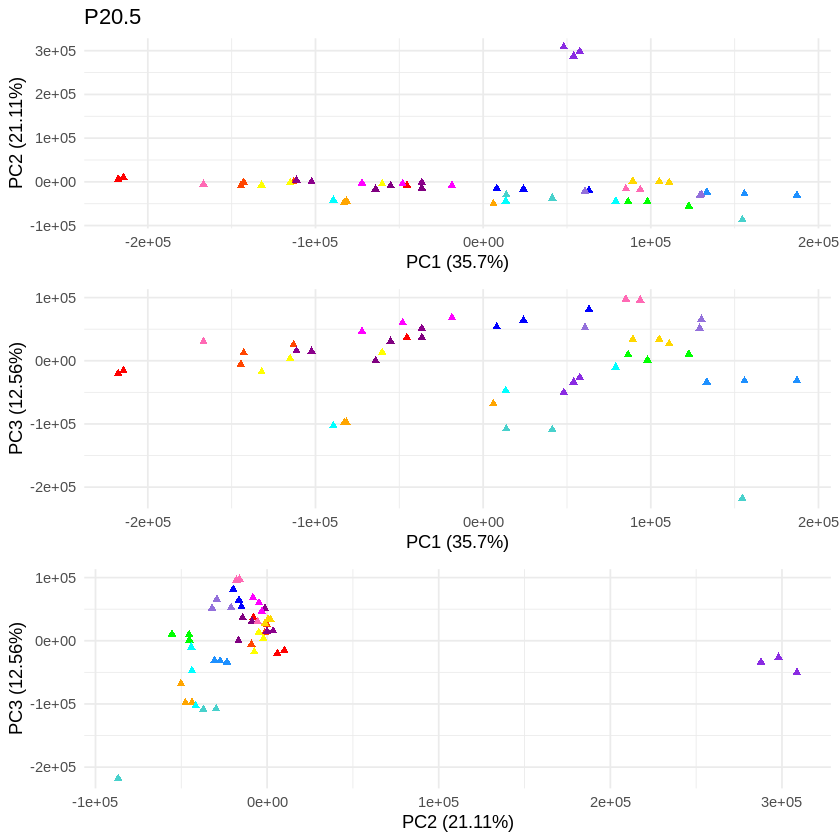

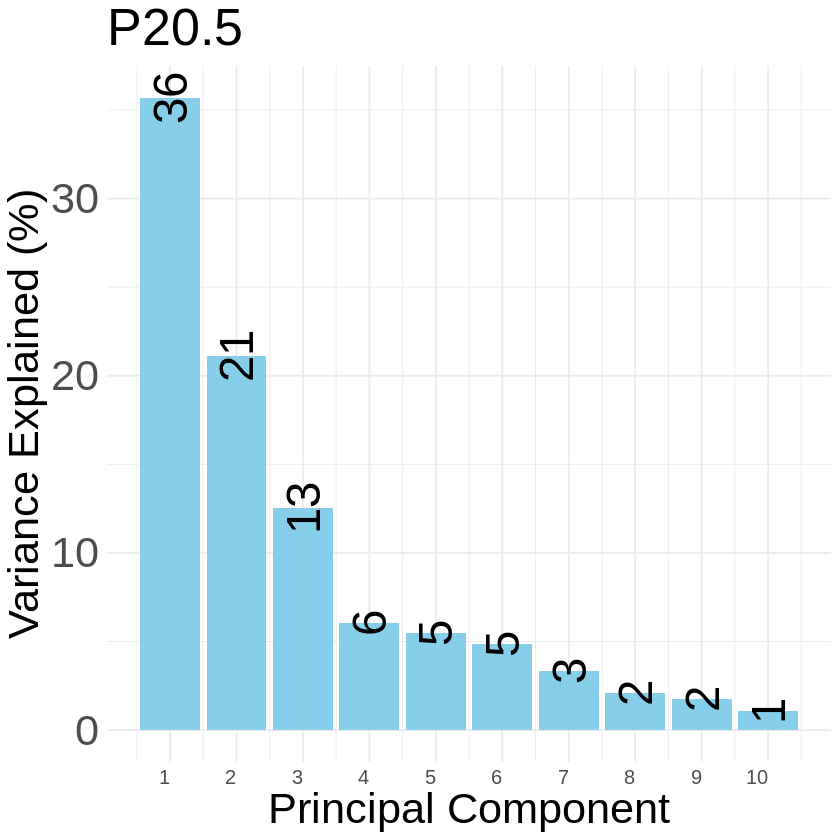

In [12]:
library(edgeR)
library(ggplot2)
library(gridExtra)

# Sample data for illustration purposes
set.seed(123)

samplenames_order =  c('C57BL_6NJ','C57BL_6NJ','C57BL_6NJ',
'BALB_cJ','BALB_cJ','BALB_cJ',
'A_J','A_J','A_J',
'FVB_NJ','FVB_NJ','FVB_NJ',
'C3H_HeJ','C3H_HeJ','C3H_HeJ','LP_J',
'129S1_SvImJ','129S1_SvImJ','129S1_SvImJ',
'DBA_2J','DBA_2J','DBA_2J',
'AKR_J','AKR_J','AKR_J',
'CBA_J','CBA_J','CBA_J',
'NOD_ShiLtJ','NOD_ShiLtJ','NOD_ShiLtJ','NZO_HlLtJ',
'WSB_EiJ','WSB_EiJ','WSB_EiJ',
'CAST_EiJ','CAST_EiJ','CAST_EiJ',
'PWK_PhJ','PWK_PhJ','PWK_PhJ',
'SPRET_EiJ','SPRET_EiJ','SPRET_EiJ')


# Perform PCA on normalized count data
pca <- prcomp(t(norm_counts))



# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Generate a color palette based on the number of unique sample names

custom_colors <- c(
  '#FF0000',  # Bright Red
  '#00FF00',  # Bright Green
  '#0000FF',  # Bright Blue
  '#FF00FF',  # Bright Magenta
  '#FFFF00',  # Bright Yellow
  '#00FFFF',  # Bright Cyan
  '#FFA500',  # Orange
  '#800080',  # Purple
  '#FF4500',  # Deep Orange
  '#8B008B',  # Dark Magenta
  '#FF69B4',  # Hot Pink
  '#48D1CC',  # Teal
  '#9370DB',  # Lavender
  '#1E90FF',  # Royal Blue
  '#FFD700',  # Gold
  '#8A2BE2',  # Blue Violet
  '#FF6347',  # Tomato
  '#008000'   # Dark Green
)
# Create a data frame for PCA results and variance explained
pca_data <- data.frame(PC1 = pca$x[, 1], PC2 = pca$x[, 2], PC3 = pca$x[, 3], Strains = sampleName,
                       Variance_PC1 = variance_explained[1], Variance_PC2 = variance_explained[2], Variance_PC3 = variance_explained[3])

# Create individual PCA plots with unique colors
  # Create a new column 'Shape' based on the sample names
pca_data$Shape <- ifelse(grepl("12.5", pca_data$Strains ), "P12.5",
            ifelse(grepl("16.5", pca_data$Strains ), "P20.5",
                   ifelse(grepl("20.5", pca_data$Strains ), "P20.5", "D")))
# Extract unique strain names from the "Strains" column
pca_data$Unique_Strains <- sapply(strsplit(pca_data$Strains, "-"), function(x) x[1])

pca_data


# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100




# Create individual PCA plots with unique colors
# Create individual PCA plots with unique colors and shapes for the legend
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs(title = "P20.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 

pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 


pca_plot_pc2_pc3 <- ggplot(pca_data, aes(x = PC2, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point() +
  scale_color_manual(values = custom_colors,breaks = unique(samplenames_order)) + 
  labs( x = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  theme_minimal() + labs(shape = "Timepoint")  +
  theme(legend.position = "none") 






# Create a custom layout matrix for vertical arrangement
layout_mat <- rbind(c(1), c(2), c(3))
# Define custom widths for each plot
custom_widths <- c(15, 15, 15)  # Adjust these values as needed
custom_heights <- c(3, 3, 3) 

# Create the grid of PCA plots
grid <- grid.arrange(pca_plot_pc1_pc2, pca_plot_pc1_pc3, pca_plot_pc2_pc3,
                     nrow = 3, ncol = 1, layout_matrix = layout_mat, widths = c(0.5), heights = custom_heights)

# Show the grid
print(grid)
# Save the grid as a PDF file
ggsave("P20.5_deseq2_PCA.pdf", grid, width = 3, height = 5, units = "in")

# Calculate the variance explained by each PC
variance_explained <- pca$sdev^2 / sum(pca$sdev^2) * 100

# Create a data frame for variance explained by first 10 PCs
variance_df <- data.frame(PC = 1:10, VarianceExplained = variance_explained[1:10])

# Create a bar plot with labels on bars and sky blue color
variance_bar_plot <- ggplot(variance_df, aes(x = PC, y = VarianceExplained, label = round(VarianceExplained, 2))) +
  geom_bar(stat = "identity", fill = "skyblue") +
  geom_text(aes(label = paste(round(VarianceExplained))),vjust = 0.5 ,size = 10, angle = 90, parse = TRUE) +  # Add text labels above the bars
  labs(title = "P20.5", title.size = 16,  # Increase title size
       x = "Principal Component", y = "Variance Explained (%)", x.size = 14, y.size = 14) +  # Increase axis label size
  theme_minimal() +
  scale_x_continuous(breaks = 1:10) +
  theme(axis.text.x = element_text(angle = 0, hjust = 1, size = 12),  # Increase x-axis label size
        axis.text.y = element_text(size = 26),  # Increase y-axis label size
        title = element_text(size = 26),  # Increase title size
        axis.title = element_text(size = 26))  # Increase axis title size
# Show the bar plot
print(variance_bar_plot)
# Save the bar plot as a PDF file
ggsave("P20.5_variance_explained_bar_plot.pdf", variance_bar_plot, width = 3, height = 4, units = "in")

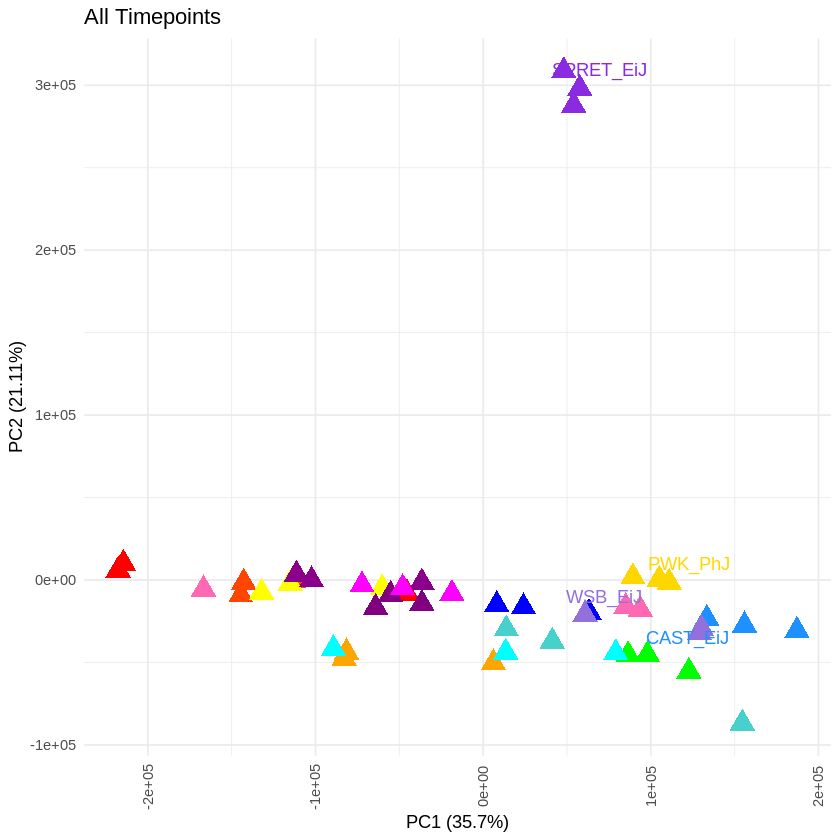

In [13]:

library(ggforce)
# Create the PCA plot
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "All Timepoints", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  theme_minimal() + 
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +  
  labs(shape = "Timepoint") + labs(color = "Strains")  +
  theme(legend.position = "none", axis.text.x = element_text(angle = 90, vjust = 0.5))  # Rotating x-axis labels




# Filter the data for specific unique strain values
selected_strains <- c("SPRET_EiJ", "WSB_EiJ", "CAST_EiJ", "PWK_PhJ")
filtered_data <- pca_data %>%
  filter(Shape == "P20.5", Unique_Strains %in% selected_strains)



# Adjust the jitter parameters for better label spacing
jitter_amount <- 4
pca_plot_pc1_pc2 <- pca_plot_pc1_pc2 +
  geom_text_repel(
    data = filtered_data %>% distinct(Unique_Strains, .keep_all = TRUE),
    aes(label = Unique_Strains, color = Unique_Strains),
    nudge_x = 0, nudge_y = 0,  # No need for nudge with jitter
    segment.color = "black",
    segment.size = 0.5,
    #arrow = arrow(type = "closed", angle = 90, length = unit(1, "inches")),
    box.padding = unit(0.4, "lines"),  # Adjust padding around labels
    point.padding = unit(0.2, "lines"),  # Adjust padding around points
    force = 10
  )

# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("P20.5_timepoint_PC1_PC2.pdf", plot = pca_plot_pc1_pc2, width = 3, height = 5)

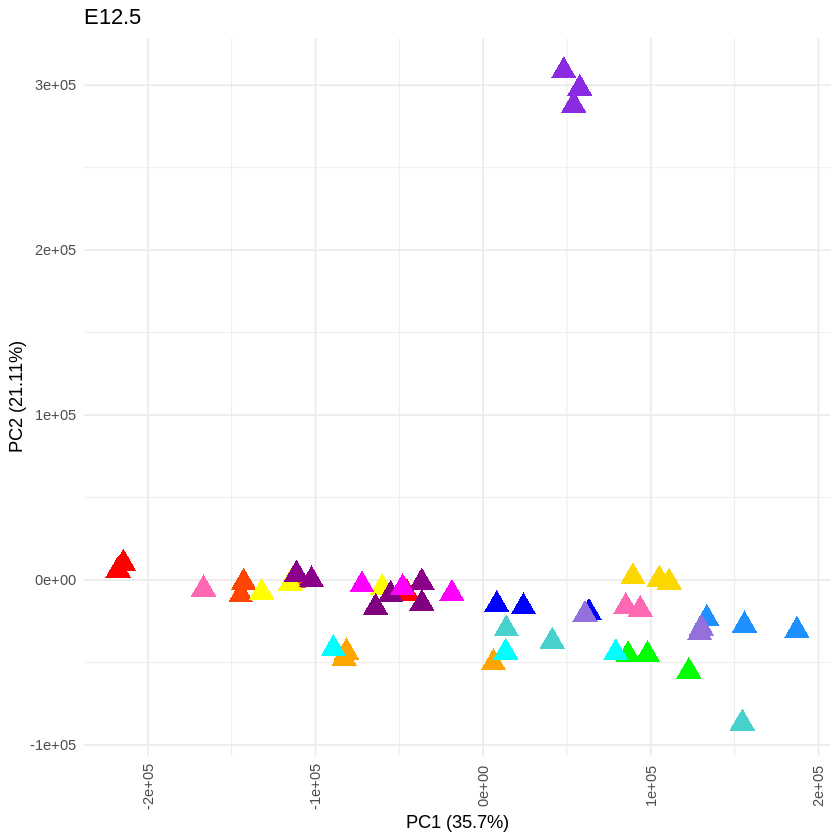

In [14]:
pca_plot_pc1_pc2 <- ggplot(pca_data, aes(x = PC1, y = PC2, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(title = "E12.5", x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC2 (", round(variance_explained[2], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) + 
  theme_minimal() +
  labs(shape = "Timepoint") +
  labs(color = "Strains") +
  theme(legend.position = "none", axis.text.x = element_text(angle = 90, vjust = 0.5))  # Rotating x-axis labels


# Print the modified PCA plot
print(pca_plot_pc1_pc2)
ggsave("P20.5_deseq2_PCA.pdf", pca_plot_pc1_pc2, width = 3, height = 5, units = "in")

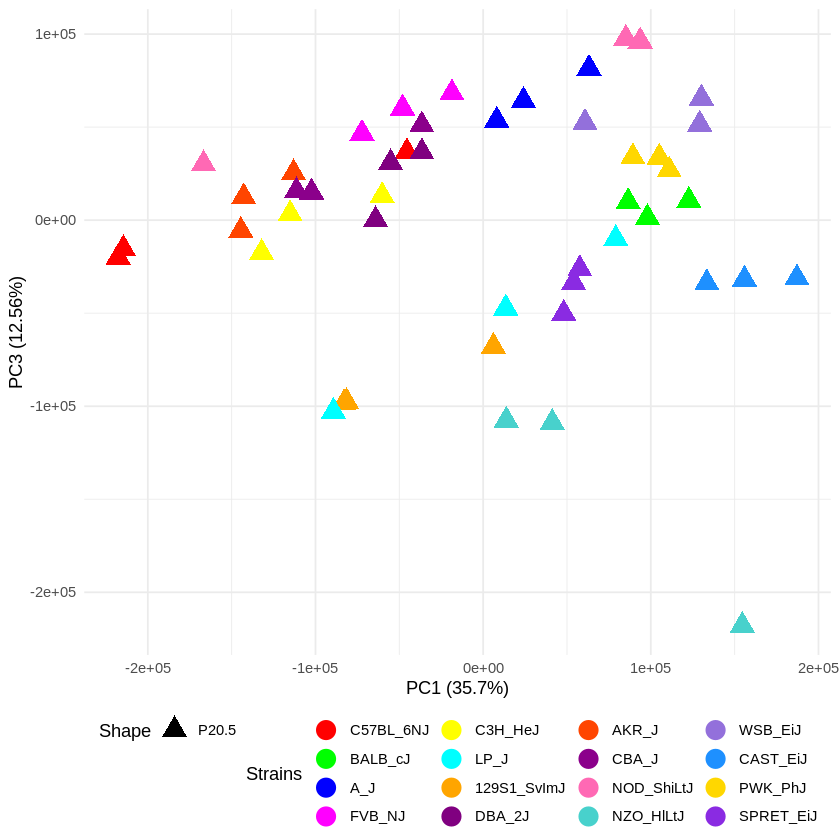

In [15]:
# Existing code (excluding the print command)
pca_plot_pc1_pc3 <- ggplot(pca_data, aes(x = PC1, y = PC3, color = Unique_Strains, shape = Shape)) +
  geom_point(size=5) +
  scale_color_manual(values = custom_colors, breaks = unique(samplenames_order)) + 
  labs(x = paste("PC1 (", round(variance_explained[1], 2), "%)", sep = ""), 
       y = paste("PC3 (", round(variance_explained[3], 2), "%)", sep = "")) +
  scale_shape_manual(values = c("E16.5" = 3, "P12.5" = 1, "P20.5" = 17, "D" = 19)) +
  labs(color = "Strains") +
  theme_minimal() +
  theme(legend.direction = "horizontal", legend.position = "bottom")

# Adjust the width of the plot
pca_plot_pc1_pc3 <- pca_plot_pc1_pc3 + theme(legend.box = "horizontal") +
  theme(legend.margin = margin(t = 0, unit = "cm"), 
        legend.spacing = unit(0.2, "cm"))

# Print the plot
print(pca_plot_pc1_pc3)


In [16]:
install.packages("pheatmap")

[1] "129S1_SvImJ-P20.5.1" "129S1_SvImJ-P20.5.2" "129S1_SvImJ-P20.5.3"
 [4] "A_J-P20.5.1"         "A_J-P20.5.2"         "A_J-P20.5.3"        
 [7] "AKR_J-P20.5.1"       "AKR_J-P20.5.2"       "AKR_J-P20.5.3"      
[10] "BALB_cJ-P20.5.1"     "BALB_cJ-P20.5.2"     "BALB_cJ-P20.5.3"    
[13] "C3H_HeJ-P20.5.1"     "C3H_HeJ-P20.5.2"     "C3H_HeJ-P20.5.3"    
[16] "C57BL_6NJ-P20.5.1"   "C57BL_6NJ-P20.5.2"   "C57BL_6NJ-P20.5.3"  
[19] "CAST_EiJ-P20.5.1"    "CAST_EiJ-P20.5.2"    "CAST_EiJ-P20.5.3"   
[22] "CBA_J-P20.5.1"       "CBA_J-P20.5.2"       "CBA_J-P20.5.3"      
[25] "DBA_2J-P20.5.1"      "DBA_2J-P20.5.2"      "DBA_2J-P20.5.3"     
[28] "FVB_NJ-P20.5.1"      "FVB_NJ-P20.5.2"      "FVB_NJ-P20.5.3"     
[31] "LP_J-P20.5.1"        "LP_J-P20.5.2"        "LP_J-P20.5.3"       
[34] "NOD_ShiLtJ-P20.5.1"  "NOD_ShiLtJ-P20.5.2"  "NOD_ShiLtJ-P20.5.3" 
[37] "NZO_HlLtJ-P20.5.1"   "NZO_HlLtJ-P20.5.2"   "NZO_HlLtJ-P20.5.3"  
[40] "PWK_PhJ-P20.5.1"     "PWK_PhJ-P20.5.2"     "PWK_PhJ-P20.5.3"    
[43] "SPRET_EiJ-P20.5.1"   "SPRET_EiJ-P20.5.2"   "SPRET_EiJ-P20.5.3"  
[46] "WSB_EiJ-P20.5.1"     "WSB_EiJ-P20.5.2"     "WSB_EiJ-P20.5.3"

TTGGCTAAGATCAAGTGTAGTATCTGTTCT
TCAATAAATATTTGTAGAATGCATGAATGA
TACCAGTTGGATAATGCACTTCCTATT
TTGGAGATTGAATTTTTGAAAAAGCCT
ATGCATTGTAGGATGATTGGCACTATC
TGATACAATTTCTAAGGGCTGTTTAGTAAT


,129S1_SvImJ-P20.5,A_J-P20.5,AKR_J-P20.5,BALB_cJ-P20.5,C3H_HeJ-P20.5,C57BL_6NJ-P20.5,CAST_EiJ-P20.5,CBA_J-P20.5,DBA_2J-P20.5,FVB_NJ-P20.5,LP_J-P20.5,NOD_ShiLtJ-P20.5,NZO_HlLtJ-P20.5,PWK_PhJ-P20.5,SPRET_EiJ-P20.5,WSB_EiJ-P20.5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,250569.18,125162.15,258910.46,113501.91,261752.77,340945.37,84670.72,232609.14,187732.87,199534.50,200772.39,153418.78,131680.39,112815.70,174758.11,86822.46
TCAATAAATATTTGTAGAATGCATGAATGA,142861.33,65152.89,77606.18,106390.68,103504.03,64059.88,166662.07,82749.26,77137.07,74541.77,121609.37,70565.56,250525.53,107119.05,118926.42,86642.04
TACCAGTTGGATAATGCACTTCCTATT,127837.56,82547.21,44325.17,145500.12,54952.58,62957.61,99072.14,51963.28,59654.39,66493.10,121368.96,74014.77,113391.48,106409.22,0.00,119605.90
TTGGAGATTGAATTTTTGAAAAAGCCT,58811.67,53544.66,41251.30,44063.57,55662.76,51867.79,33665.31,41876.41,74249.37,48413.40,56492.02,49409.66,69369.52,0.00,0.00,31269.38
ATGCATTGTAGGATGATTGGCACTATC,62214.05,46571.47,48012.71,28111.46,41966.73,25943.27,18792.84,39015.58,69791.38,34071.41,64596.62,22558.46,39861.39,24138.82,31126.46,21125.16
TGATACAATTTCTAAGGGCTGTTTAGTAAT,58399.41,32605.78,56295.28,30005.85,41947.84,49856.27,27072.12,52532.82,36308.81,44145.60,59155.16,39382.57,41000.23,28412.68,34014.10,26073.01


[1] 15472244

[1] 3959

,129S1_SvImJ-P20.5,A_J-P20.5,AKR_J-P20.5,BALB_cJ-P20.5,C3H_HeJ-P20.5,C57BL_6NJ-P20.5,CAST_EiJ-P20.5,CBA_J-P20.5,DBA_2J-P20.5,FVB_NJ-P20.5,LP_J-P20.5,NOD_ShiLtJ-P20.5,NZO_HlLtJ-P20.5,PWK_PhJ-P20.5,SPRET_EiJ-P20.5,WSB_EiJ-P20.5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,250569.18,125162.15,258910.46,113501.91,261752.77,340945.37,84670.72,232609.14,187732.87,199534.50,200772.39,153418.78,131680.39,112815.70,174758.11,86822.46
TCAATAAATATTTGTAGAATGCATGAATGA,142861.33,65152.89,77606.18,106390.68,103504.03,64059.88,166662.07,82749.26,77137.07,74541.77,121609.37,70565.56,250525.53,107119.05,118926.42,86642.04
TACCAGTTGGATAATGCACTTCCTATT,127837.56,82547.21,44325.17,145500.12,54952.58,62957.61,99072.14,51963.28,59654.39,66493.10,121368.96,74014.77,113391.48,106409.22,0.00,119605.90
TTGGAGATTGAATTTTTGAAAAAGCCT,58811.67,53544.66,41251.30,44063.57,55662.76,51867.79,33665.31,41876.41,74249.37,48413.40,56492.02,49409.66,69369.52,0.00,0.00,31269.38
ATGCATTGTAGGATGATTGGCACTATC,62214.05,46571.47,48012.71,28111.46,41966.73,25943.27,18792.84,39015.58,69791.38,34071.41,64596.62,22558.46,39861.39,24138.82,31126.46,21125.16
TGATACAATTTCTAAGGGCTGTTTAGTAAT,58399.41,32605.78,56295.28,30005.85,41947.84,49856.27,27072.12,52532.82,36308.81,44145.60,59155.16,39382.57,41000.23,28412.68,34014.10,26073.01


,129S1_SvImJ-P20.5,A_J-P20.5,AKR_J-P20.5,BALB_cJ-P20.5,C3H_HeJ-P20.5,C57BL_6NJ-P20.5,CAST_EiJ-P20.5,CBA_J-P20.5,DBA_2J-P20.5,FVB_NJ-P20.5,LP_J-P20.5,NOD_ShiLtJ-P20.5,NZO_HlLtJ-P20.5,PWK_PhJ-P20.5,SPRET_EiJ-P20.5,WSB_EiJ-P20.5,ID
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TTGGCTAAGATCAAGTGTAGTATCTGTTCT,250569.18,125162.15,258910.46,113501.91,261752.77,340945.37,84670.72,232609.14,187732.87,199534.50,200772.39,153418.78,131680.39,112815.70,174758.11,86822.46,TTGGCTAAGATCAAGTGTAGTATCTGTTCT
TCAATAAATATTTGTAGAATGCATGAATGA,142861.33,65152.89,77606.18,106390.68,103504.03,64059.88,166662.07,82749.26,77137.07,74541.77,121609.37,70565.56,250525.53,107119.05,118926.42,86642.04,TCAATAAATATTTGTAGAATGCATGAATGA
TACCAGTTGGATAATGCACTTCCTATT,127837.56,82547.21,44325.17,145500.12,54952.58,62957.61,99072.14,51963.28,59654.39,66493.10,121368.96,74014.77,113391.48,106409.22,0.00,119605.90,TACCAGTTGGATAATGCACTTCCTATT
TTGGAGATTGAATTTTTGAAAAAGCCT,58811.67,53544.66,41251.30,44063.57,55662.76,51867.79,33665.31,41876.41,74249.37,48413.40,56492.02,49409.66,69369.52,0.00,0.00,31269.38,TTGGAGATTGAATTTTTGAAAAAGCCT
ATGCATTGTAGGATGATTGGCACTATC,62214.05,46571.47,48012.71,28111.46,41966.73,25943.27,18792.84,39015.58,69791.38,34071.41,64596.62,22558.46,39861.39,24138.82,31126.46,21125.16,ATGCATTGTAGGATGATTGGCACTATC
TGATACAATTTCTAAGGGCTGTTTAGTAAT,58399.41,32605.78,56295.28,30005.85,41947.84,49856.27,27072.12,52532.82,36308.81,44145.60,59155.16,39382.57,41000.23,28412.68,34014.10,26073.01,TGATACAATTTCTAAGGGCTGTTTAGTAAT


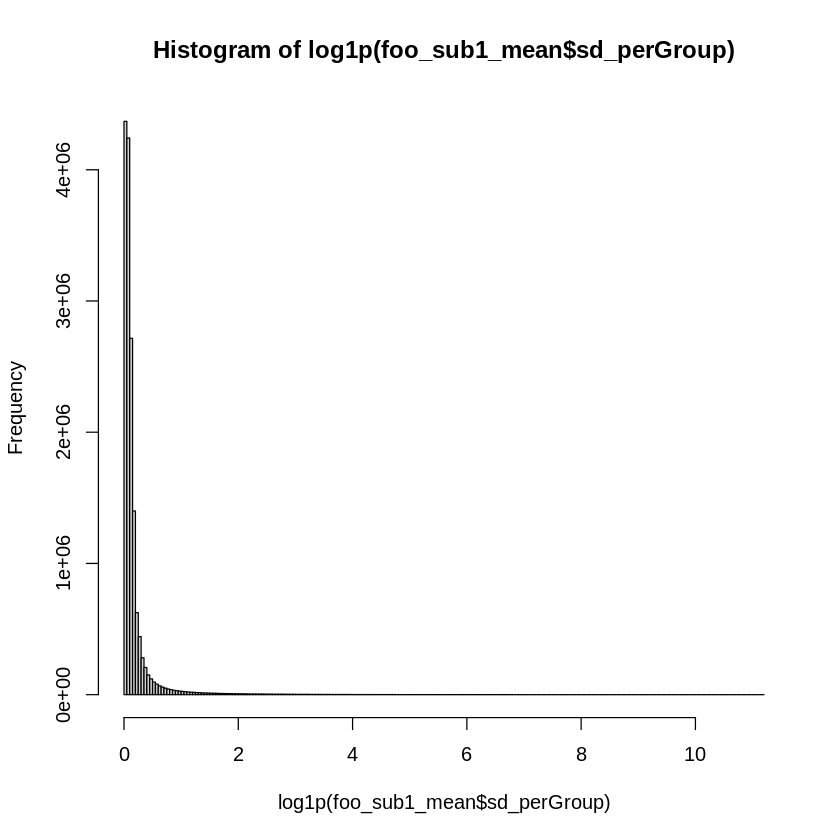

png 
  2

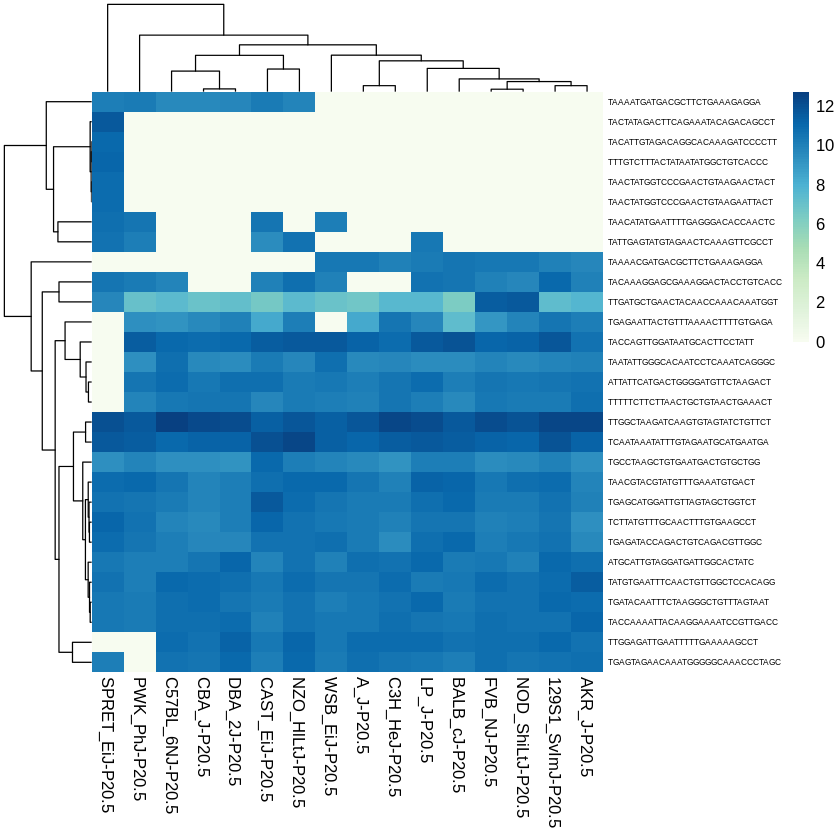

In [18]:

##NEXT IS THE TOP 15% VARIANT miRNA plot on the means. Then the subset more useful miRNA plot
library(pheatmap)
library(gplots)

foo_sub_1 <- as.data.frame.matrix(norm_counts) #convert from matrix to data frame
## use for eg foo$`hPGC_M_Wk9_n1` <- foo$`hPGC-M-Wk9_2` if only want one biol replicate

colnames(foo_sub_1)

head(foo_sub_1[ , grepl( "^129S1_SvImJ-20.5dpp" , names( foo_sub_1 ) ) ])
foo_sub1_mean = data.frame(matrix(NA, nrow = nrow(foo_sub_1), ncol = 0))
row.names(foo_sub1_mean) <- row.names(foo_sub_1)
for (sample in sampleName) {
foo_sub1_mean[sample] <- apply(foo_sub_1[ , grepl(paste0( "^",sample) , names( foo_sub_1 ) ) ], 1, mean)
}
head(foo_sub1_mean) 

foo_sub1_mean$sd_perGroup <- apply(foo_sub1_mean,1,sd)
hist(log1p(foo_sub1_mean$sd_perGroup),breaks = 200)


nrow(foo_sub1_mean)
3959
foo_sub1_mean_top15sd <- foo_sub1_mean[foo_sub1_mean$sd_perGroup>10959,1:16]
head(foo_sub1_mean_top15sd)
foo_sub1_mean_top15sd$ID<-rownames(foo_sub1_mean_top15sd)
head(foo_sub1_mean_top15sd)



save_pheatmap_pdf <- function(x, filename, width=15, height=25) {
    stopifnot(!missing(x))
    stopifnot(!missing(filename))
    pdf(filename, width=width, height=height,paper="special")
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}


savePheatmap <- pheatmap(log1p(foo_sub1_mean_top15sd[,1:16]),width=2,height=3, border_color = NA,show_rownames = T, cluster_cols = False, labels_row = foo_sub1_mean_top15sd$ID,fontsize_row = 5, color = hmcol)


save_pheatmap_pdf(savePheatmap,"P20.5_InitialPheatMap.pdf")

png 
  2

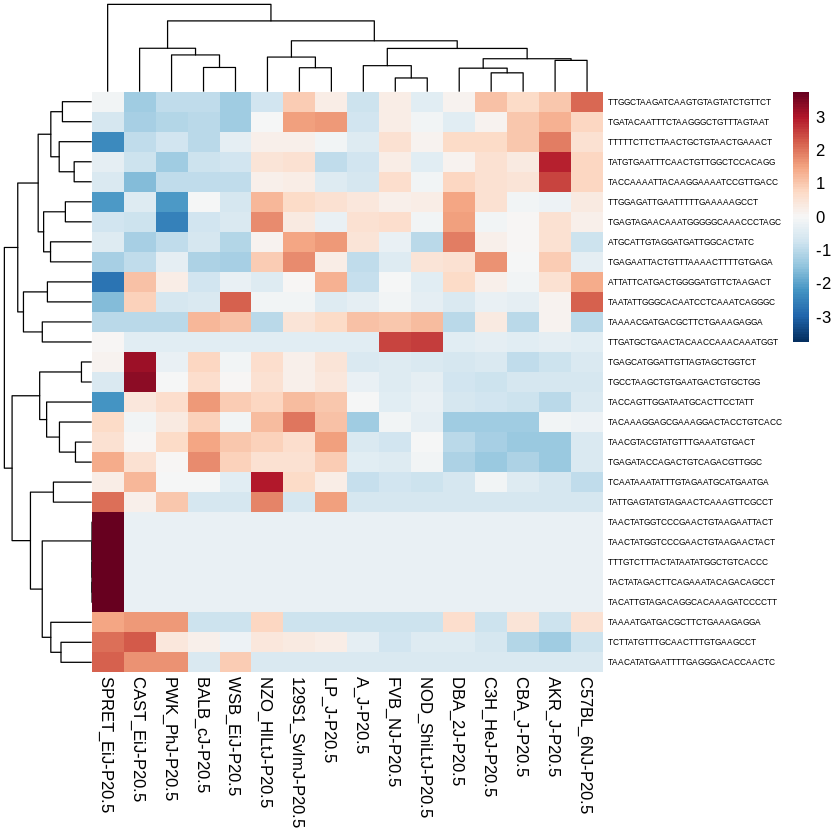

In [19]:
library(gplots)
library(RColorBrewer)
##for z-score
myCol <- rev(colorRampPalette(brewer.pal(11, "RdBu"))(100))



savePheatmapZScore <- pheatmap(foo_sub1_mean_top15sd[,1:16],,width=2,height=3, border_color = NA,show_rownames = T, cluster_cols = False,scale = "row",labels_row = foo_sub1_mean_top15sd$ID,fontsize_row = 5, color = myCol)

save_pheatmap_pdf(savePheatmapZScore,"P20.5_InitialPheatMap_zScore.pdf")

Detecting marker genes...
Done! 
